# Task-03: Decision Tree Classifier — Bank Marketing

**Objective:** Build a Decision Tree Classifier to predict whether a bank customer will subscribe to a term deposit (`yes` / `no`) using demographic and behavioral data.

**Dataset:** UCI Bank Marketing Dataset.

**Workflow:** Data loading → cleaning → EDA → preprocessing → train/test split → Decision Tree → evaluation → feature importance → prediction → conclusion.


In [1]:
# Import required libraries
import os
import zipfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load the Dataset

The notebook first looks for `bank-full.csv`. If it is not present, it automatically downloads the official UCI Bank Marketing archive in Google Colab.


In [3]:
# Load the official UCI Bank Marketing dataset automatically
local_files = ["/content/Bank_Marketing_Dataset.csv"]

if os.path.exists(local_files[0]):
    data_path = local_files[0]
    df = pd.read_csv(data_path, sep=";")
elif os.path.exists(local_files[1]):
    data_path = local_files[1]
    df = pd.read_csv(data_path, sep=";")
else:
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    zip_path = "/content/bank_marketing.zip"
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        member = [x for x in z.namelist() if x.endswith("bank-full.csv")][0]
        z.extract(member, "/content/")
        data_path = "/content/" + member
    df = pd.read_csv(data_path, sep=";")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,43,blue-collar,married,primary,no,4152,yes,no,cellular,18,may,147,2,-1,0,unknown,no
1,29,blue-collar,married,primary,no,334,no,no,unknown,28,jun,104,3,-1,0,unknown,no
2,48,blue-collar,married,secondary,no,1632,yes,no,telephone,13,jan,201,3,-1,0,unknown,no
3,50,management,married,secondary,no,-576,yes,yes,unknown,14,may,442,3,-1,0,unknown,no
4,20,blue-collar,divorced,tertiary,no,654,yes,no,unknown,27,aug,197,3,-1,0,unknown,no


## 2. Understand the Data


In [4]:
# Basic information
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nTarget distribution:")
display(df["y"].value_counts().to_frame("count"))
display((df["y"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))


Shape: (4521, 17)

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Missing values:


,missing_values
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0



Target distribution:


,count
y,
no,3980
yes,541


,percentage
y,
no,88.03
yes,11.97


In [5]:
# Statistical summary
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4521.0,NaN,NaN,NaN,39.887414,10.329138,18.0,33.0,40.0,47.0,76.0
job,4521,12,blue-collar,983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4521,3,married,2708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4521,4,secondary,2285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4521,2,no,4423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,4521.0,NaN,NaN,NaN,962.699624,2334.833955,-868.0,-318.0,253.0,1302.0,29661.0
housing,4521,2,yes,2514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4521,2,no,3810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4521,3,cellular,2893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,4521.0,NaN,NaN,NaN,16.094006,9.047992,1.0,8.0,16.0,24.0,31.0


## 3. Exploratory Data Analysis


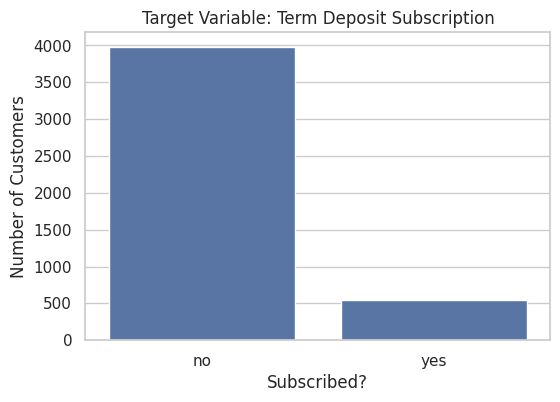

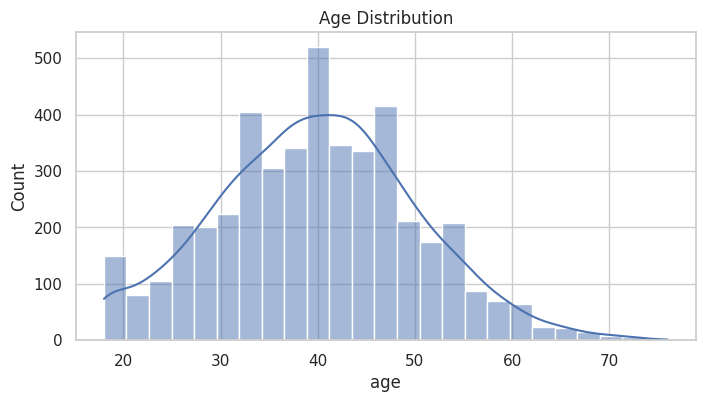

In [6]:
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="y")
plt.title("Target Variable: Term Deposit Subscription")
plt.xlabel("Subscribed?")
plt.ylabel("Number of Customers")
plt.show()

# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="age", bins=25, kde=True)
plt.title("Age Distribution")
plt.show()


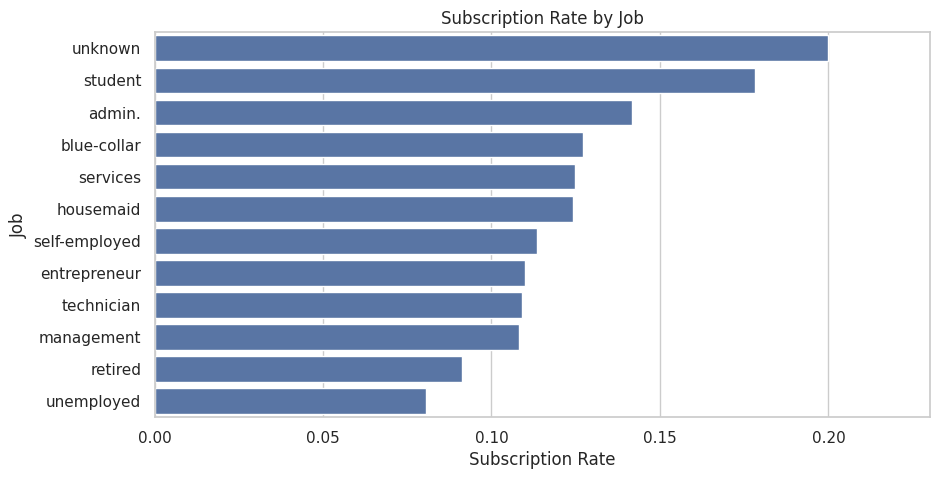

In [7]:
# Subscription rate by job
job_rate = df.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=job_rate.values, y=job_rate.index)
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate")
plt.ylabel("Job")
plt.xlim(0, max(job_rate.values) * 1.15)
plt.show()


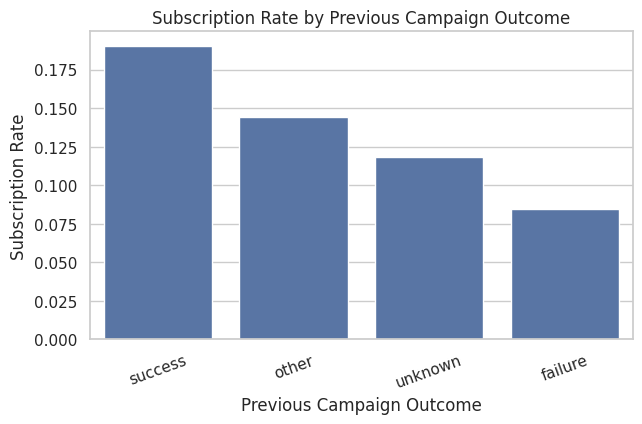

In [8]:
# Subscription rate by previous campaign outcome
pout_rate = df.groupby("poutcome")["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=pout_rate.index, y=pout_rate.values)
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=20)
plt.show()


## 4. Data Preprocessing

The target variable `y` is converted into 0/1. Categorical variables are one-hot encoded using `OneHotEncoder`, while numeric variables are passed through unchanged.

A stratified 80:20 split is used so that the proportion of subscribers is preserved in both training and test sets.


In [9]:
# Separate features and target
X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Training rows: 3616
Testing rows: 905


## 5. Build the Decision Tree Classifier


In [10]:
# Decision Tree model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)
print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


## 6. Model Evaluation


In [11]:
# Predictions
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"], zero_division=0))


Accuracy : 0.7757
Precision: 0.2589
Recall   : 0.4722
F1-Score : 0.3344

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.82      0.87       797
         Yes       0.26      0.47      0.33       108

    accuracy                           0.78       905
   macro avg       0.59      0.64      0.60       905
weighted avg       0.84      0.78      0.80       905



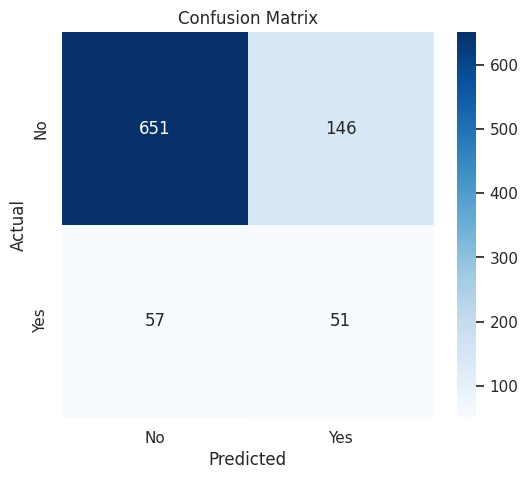

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 7. Visualize the Decision Tree


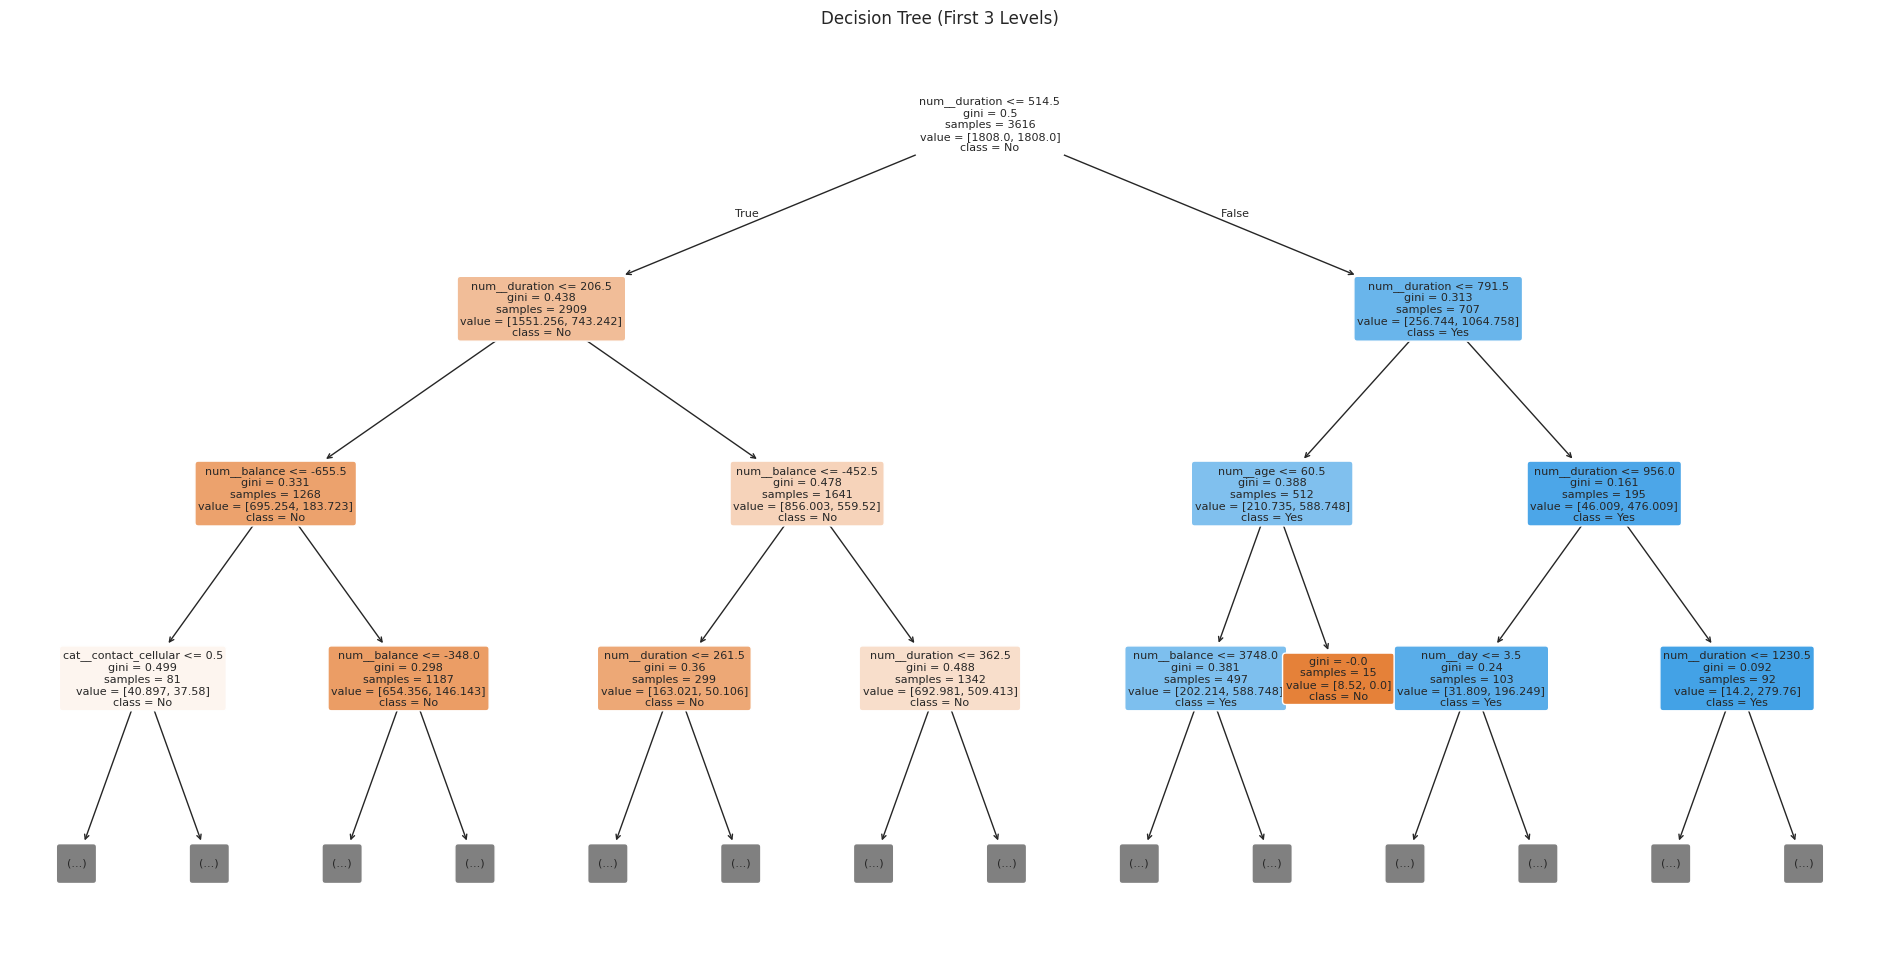

In [13]:
# Transform the training data so that the tree can be visualized
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
tree_model = model.named_steps["classifier"]

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree (First 3 Levels)")
plt.show()


## 8. Feature Importance


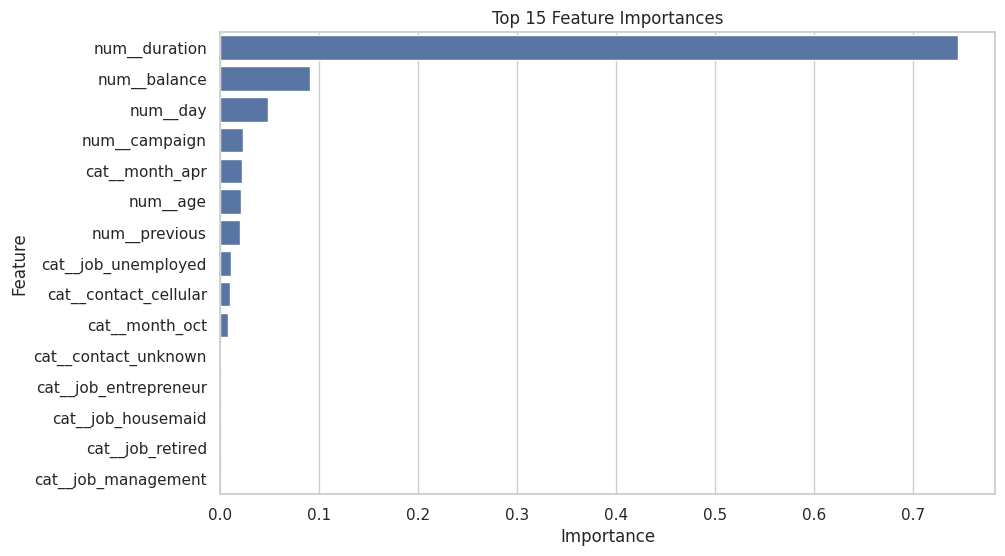

,importance
num__duration,0.745750
num__balance,0.090525
num__day,0.048163
num__campaign,0.023382
cat__month_apr,0.022269
num__age,0.020751
num__previous,0.019848
cat__job_unemployed,0.010967
cat__contact_cellular,0.010179
cat__month_oct,0.007777


In [14]:
# Feature importance
importance = pd.Series(
    tree_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_importance = importance.head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_importance.values, y=top_importance.index)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(top_importance.to_frame("importance"))


## 9. Example Customer Prediction


In [15]:
# Predict one customer from the test set
sample_customer = X_test.iloc[[0]]
sample_prediction = model.predict(sample_customer)[0]

print("Customer details:")
display(sample_customer)

print("Predicted subscription:", "Yes" if sample_prediction == 1 else "No")


Customer details:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
2345,30,technician,single,secondary,no,-258,no,no,cellular,22,jul,518,1,-1,0,unknown


Predicted subscription: Yes


## 10. Conclusion

The Decision Tree Classifier successfully learns patterns from demographic, financial and campaign-related variables to predict whether a customer is likely to subscribe to a bank term deposit.

**Key points:**
- Categorical variables were encoded using one-hot encoding.
- The data was split using stratification to preserve class proportions.
- A Decision Tree Classifier was trained and evaluated using accuracy, precision, recall and F1-score.
- A confusion matrix was used to understand classification errors.
- Feature importance was used to identify variables contributing most to predictions.

**Important note:** `duration` is a strong predictor in this dataset, but it is known only after a call has taken place. Therefore, for a truly pre-call marketing model, `duration` should be excluded.


### Dataset Citation

Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306
